<a href="https://colab.research.google.com/github/25730018/colab-notebooks/blob/main/%E3%83%87%E3%83%BC%E3%82%BF%E6%8B%A1%E5%BC%B5%EF%BC%88%E5%AE%9F%E9%9A%9B%E3%81%AE%E6%B3%A2%E5%BD%A2%EF%BC%89.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


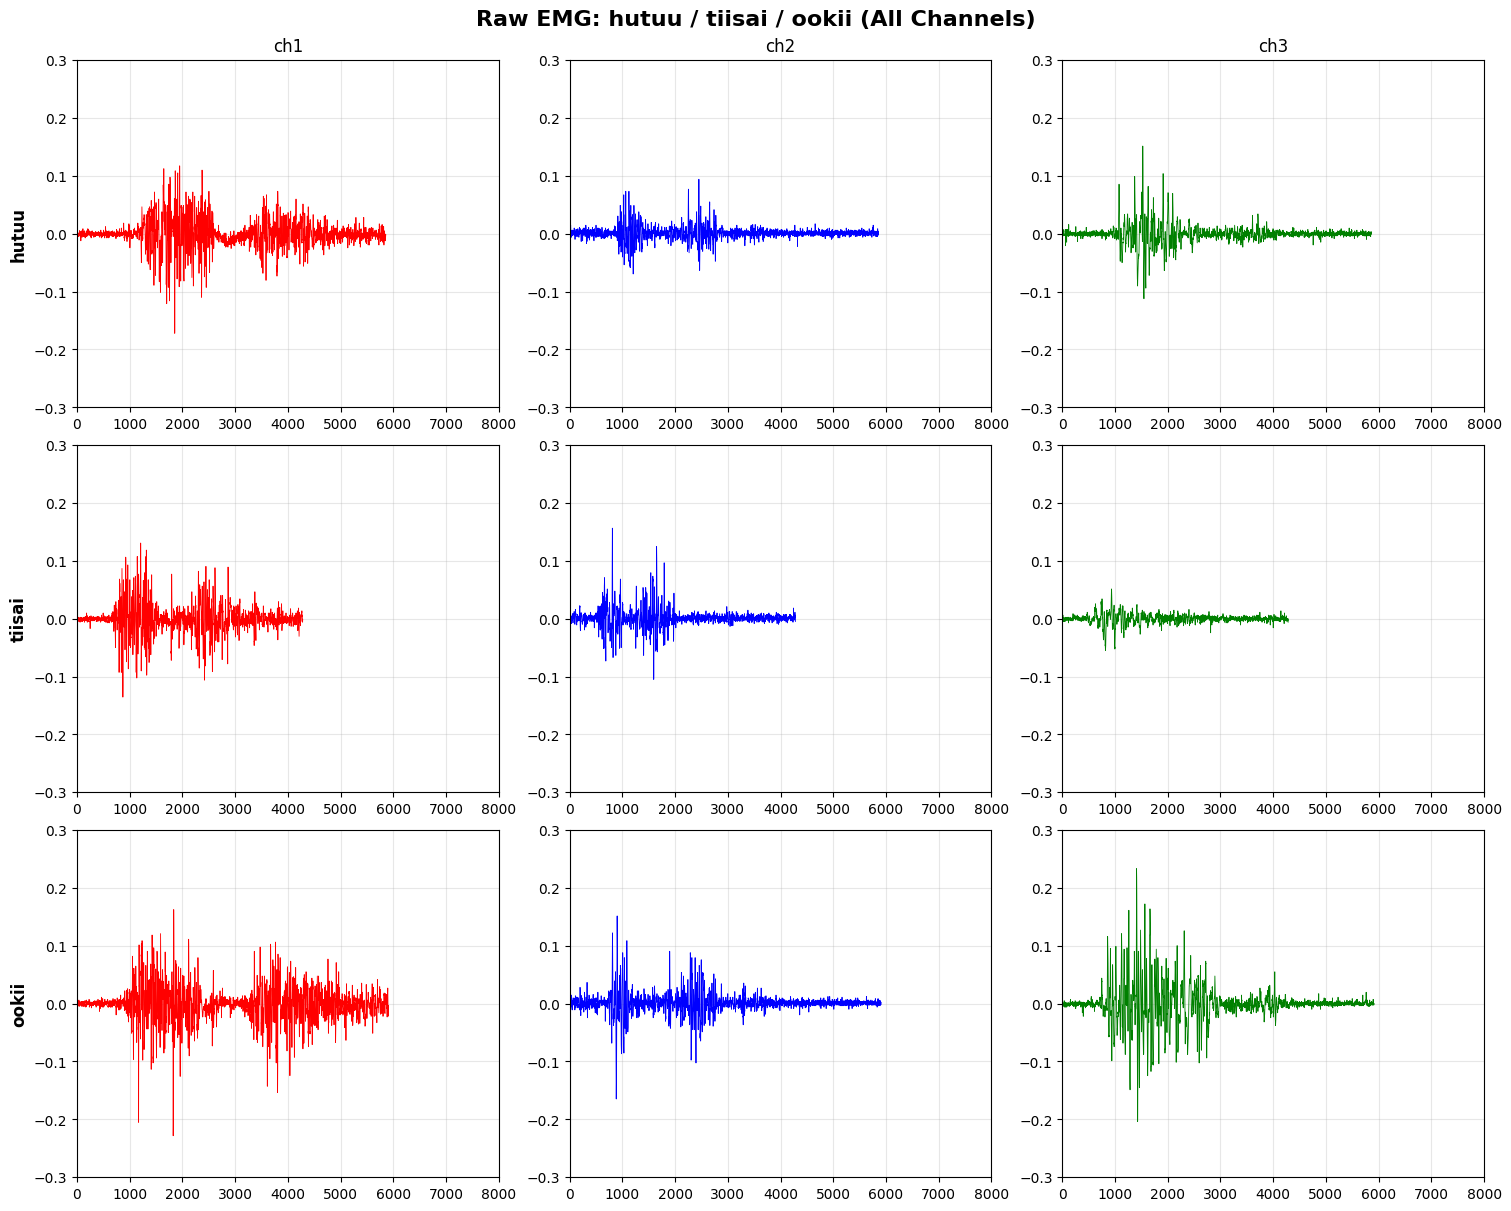

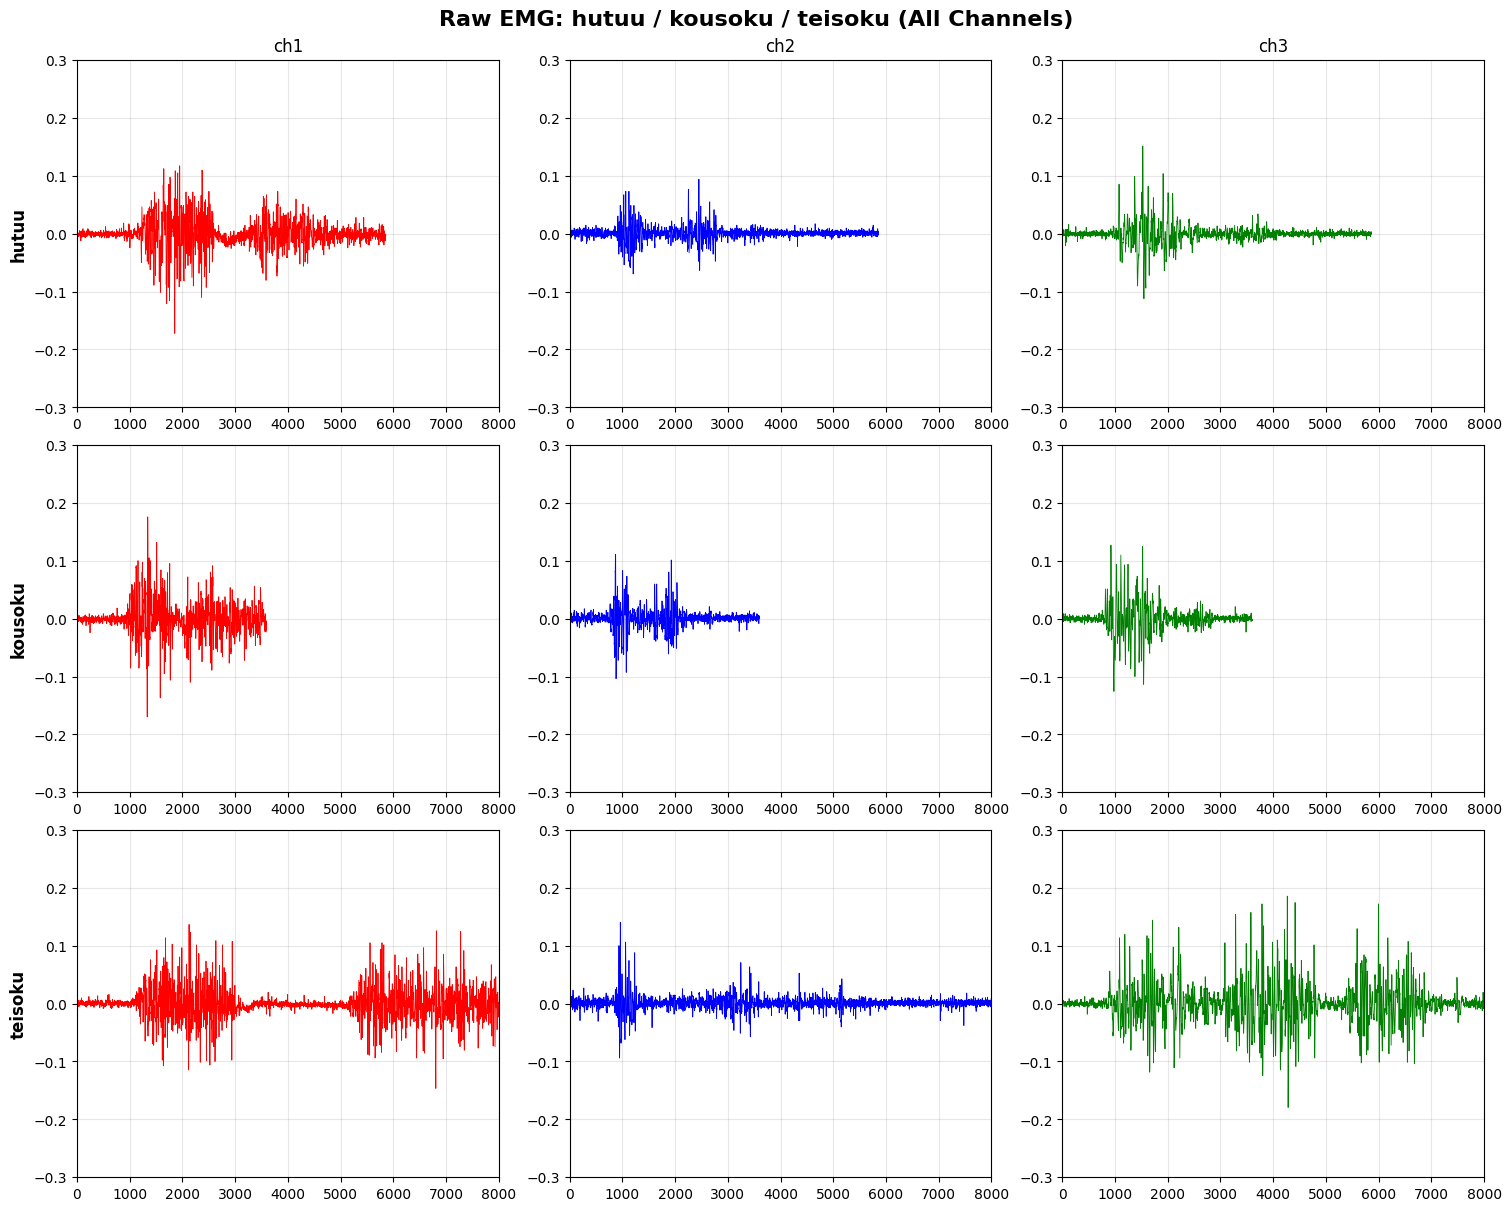

In [ ]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ========== 設定 ==========
min1 = 0
max_ = 8000
path = 'drive/MyDrive/suzuki_Data/suzuki/2025-07-17/emg2025-07-17-15-53-59/'

# ========== グループ1: hutuu, tiisai, ookii ==========
word_groups = [
    ['hutuu', 'tiisai', 'ookii'],
    ['hutuu', 'kousoku', 'teisoku'],
]

colors = ['red', 'blue', 'green']
ch_labels = ['ch1', 'ch2', 'ch3']

for group in word_groups:
    fig, axes = plt.subplots(len(group), 3, figsize=(15, 4 * len(group)), constrained_layout=True)
    title_words = ' / '.join(group)
    fig.suptitle(f"Raw EMG: {title_words} (All Channels)", fontsize=16, fontweight='bold')

    for i, word in enumerate(group):
        # CSVを1つ読み込む
        file_list = glob.glob(str(Path(path) / word / '*.csv'))
        if not file_list:
            print(f"CSVが見つかりません: {word}")
            for j in range(3):
                axes[i, j].set_visible(False)
            continue

        df = pd.read_csv(file_list[0], skiprows=13, header=None)
        raw_data = df.iloc[min1:max_, 0:3].values  # shape: (N, 3)

        for j in range(3):
            ax = axes[i, j]
            ax.plot(raw_data[:, j], color=colors[j], linewidth=0.6)
            if j == 0:
                ax.set_ylabel(word, fontsize=12, fontweight='bold')
            if i == 0:
                ax.set_title(ch_labels[j], fontsize=12)
            ax.set_ylim(-0.30, 0.30)
            ax.set_xlim(0, 8000)
            ax.grid(alpha=0.3)

    plt.show()